### Importing Necessary Libraries

In [1]:
import langchain

In [98]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_community.utilities import WikipediaAPIWrapper , SerpAPIWrapper 
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_tavily import TavilySearch
from langchain_community.tools import WikipediaQueryRun
from langchain_groq import ChatGroq
from langchain_community.tools import DuckDuckGoSearchRun


In [7]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [8]:
### creating tools for agents

In [9]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [14]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
#os.environ["SERP_API_KEY"] = os.getenv("SERP_API_KEY")
serp_key = "a3b66d4545005f0c88684ca95e381488218454a6d2f2e57475cf6ea8f6cea3b9"

### Creating Tools for LLM

In [108]:
@tool
def tavily_search(query: str) -> str:
    """
    Search the web for current events, breaking news, recent developments,
    sports results, politics, technology updates, and information after
    the model's knowledge cutoff.
    """
    tavily_result = TavilySearchResults(max_results=5).invoke(query)
    return str(tavily_result)

@tool
def wiki_search(query: str)->str:
    """
    Search Wikipedia for historical facts, concepts, biographies,
    definitions, and stable information.
    """
    wiki_wrapper = WikipediaAPIWrapper()
    wiki_result = WikipediaQueryRun(api_wrapper=wiki_wrapper).run(query)
    return wiki_result
# @tool 
# def serp_search(query: str)-> str:
#     """ This will search for the Answers of questions which are not available in LLM or you want to 
#     search something generally."""
#     serp_result = SerpAPIWrapper(serpapi_api_key=serp_key).run(query)
#     return serp_result
@tool
def duck_search(query:str):
    """
    General-purpose web search. Use when you need information from the web
    and Tavily is not appropriate.
    """
    search = DuckDuckGoSearchRun()
    result = search.invoke(query)
    return result

In [61]:
#pip install serpapi

In [109]:
tools = [tavily_search,wiki_search,duck_search]
agent = create_agent(llm,tools)

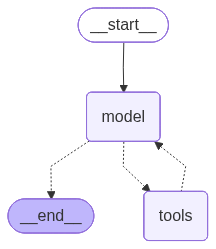

In [110]:
agent

In [111]:
from datetime import datetime

current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

In [112]:
from langchain_core.messages import HumanMessage

response = agent.invoke(
    {
        "messages": [
            HumanMessage(content="What is the latest AI news of 5th June 2026?")
        ]
    }
)

In [113]:
print(response["messages"][-1].content)

Based on the search results, the latest AI news on June 5th, 2026 includes:

* OpenAI granting the European Union access to GPT-5.5-Cyber, a variation of its latest flagship model designed for cybersecurity applications.
* Anthropic's Glasswing expanding to include critical infrastructure, with Claude now inside critical infrastructure.
* The release of Claude Sonnet 4.6 and Claude Opus 4.8, with speculation around an intermediate Claude Sonnet 4.8.
* A lawsuit filed against the planned Stratos datacenter project in Utah.
* New York considering a moratorium on new datacenters.
* Labour Party's plan to make AI "work for the workers".
* Seattle poised to ban new datacenters in a blow to big tech hub.
* California city voting to permanently ban datacenters.
* Colorado governor vetoing a block on surveillance pricing.
* A Labour MP suing Elon Musk's xAI company over fake sexualized images.
* Careers guidance being at the center of Alan Milburn's final Neet report.
* SpaceX targeting the bi

In [114]:
def agent_response(user_query: str):
    response = agent.invoke({"messages":[{"role":"system","content":f"Current date and time is {current_time}"},
                                         {"role":"user",
                                          "content":user_query}]})
    return response["messages"][-1].content

In [76]:
result = agent_response("who win IPL 2026?")
result["messages"][-1].content

'Royal Challengers Bengaluru won the IPL 2026 title by defeating Gujarat Titans in the final match.'

In [78]:
result = agent_response("what is the age of virat kohli and how old he is today ?")
result["messages"][-1].content

'Virat Kohli was born on November 5, 1988. He is currently 37 years old.'

In [79]:
result = agent_response("what is todays date?")
result["messages"][-1].content

/Users/sahildeswal/Downloads/GenAI/genai_latest/lib/python3.11/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /Users/sahildeswal/Downloads/GenAI/genai_latest/lib/python3.11/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


'The current date is 2026-06-07.'

In [80]:
import gradio as gr

In [115]:
demo = gr.Interface(fn=agent_response,inputs=["text"],outputs="text",title="Agentic AI",description="Use tools to give answer if information is not available in LLM")
demo.launch()

* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.
